# Credit Card Fraud Detection — Model Training

**Dataset:** [Kaggle — Credit Card Fraud Detection (mlg-ulb)](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)
**Environment:** Kaggle Notebook (training) → artifacts exported for local FastAPI + Streamlit app

This notebook covers:
1. Data exploration and inspection
2. Exploratory Data Analysis (EDA)
3. Handling extreme class imbalance
4. Feature scaling
5. Train/test split
6. Training and comparing Logistic Regression, Random Forest, XGBoost (+ Isolation Forest for anomaly-detection comparison)
7. Evaluation with fraud-relevant metrics
8. Model selection and justification
9. Serialization of the final model + scaler for deployment

> **Note on the dataset:** `creditcard.csv` has 284,807 transactions, of which only 492 (0.172%) are fraud — this is one of the most imbalanced classification problems commonly used for teaching. Never trust accuracy alone here: a model that predicts "legitimate" for everything would score 99.8% accuracy and catch zero fraud.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.metrics import (
    confusion_matrix, classification_report, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score, precision_recall_curve
)
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler, SMOTE
from xgboost import XGBClassifier

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
RANDOM_STATE = 42

## Phase 1 — Data Exploration and Preprocessing

### Step 1: Load and Inspect Data

In [2]:
# On Kaggle, the dataset is typically mounted at:
# /kaggle/input/creditcardfraud/creditcard.csv
# Adjust the path below if running locally.
DATA_PATH = "/kaggle/input/creditcardfraud/creditcard.csv"

try:
    df = pd.read_csv(DATA_PATH)
except FileNotFoundError:
    # Fallback for local runs — place creditcard.csv next to this notebook
    df = pd.read_csv("creditcard.csv")

print("Shape:", df.shape)
df.head()

Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [4]:
print("Missing values per column:")
print(df.isnull().sum().sum(), "total missing values")
df.describe()

Missing values per column:
0 total missing values


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


### Step 2: Exploratory Data Analysis

Class counts:
 Class
0    284315
1       492
Name: count, dtype: int64

Class percentages:
 Class
0    99.8273
1     0.1727
Name: proportion, dtype: float64


C:\Users\yahawashi\AppData\Local\Temp\ipykernel_7228\2721233141.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(['Legitimate (0)', 'Fraud (1)'])


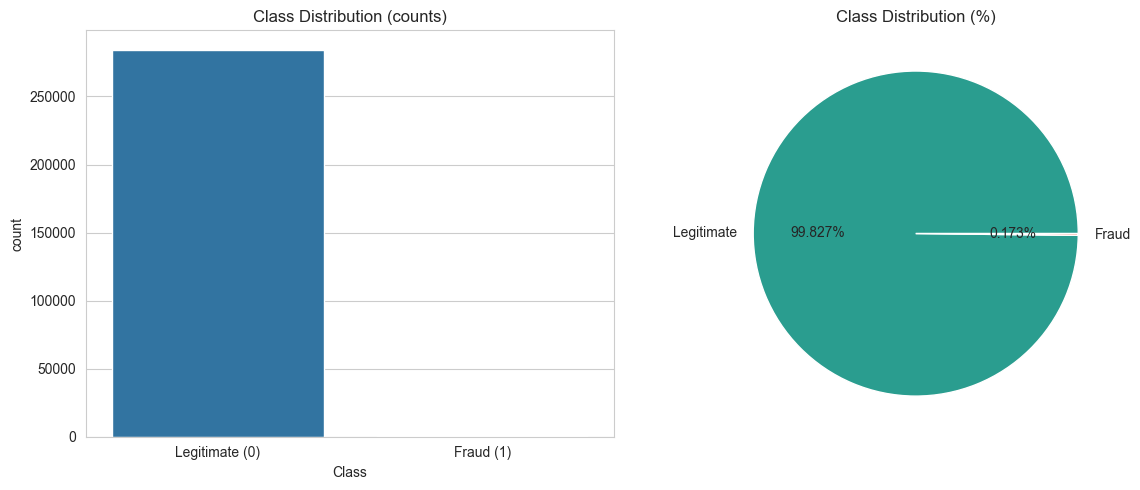

In [5]:
class_counts = df['Class'].value_counts()
class_pct = df['Class'].value_counts(normalize=True) * 100

print("Class counts:\n", class_counts)
print("\nClass percentages:\n", class_pct.round(4))

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(x='Class', data=df, ax=ax[0])
ax[0].set_title("Class Distribution (counts)")
ax[0].set_xticklabels(['Legitimate (0)', 'Fraud (1)'])

ax[1].pie(class_counts, labels=['Legitimate', 'Fraud'], autopct='%1.3f%%',
          colors=['#2a9d8f', '#e76f51'])
ax[1].set_title("Class Distribution (%)")
plt.tight_layout()
plt.show()

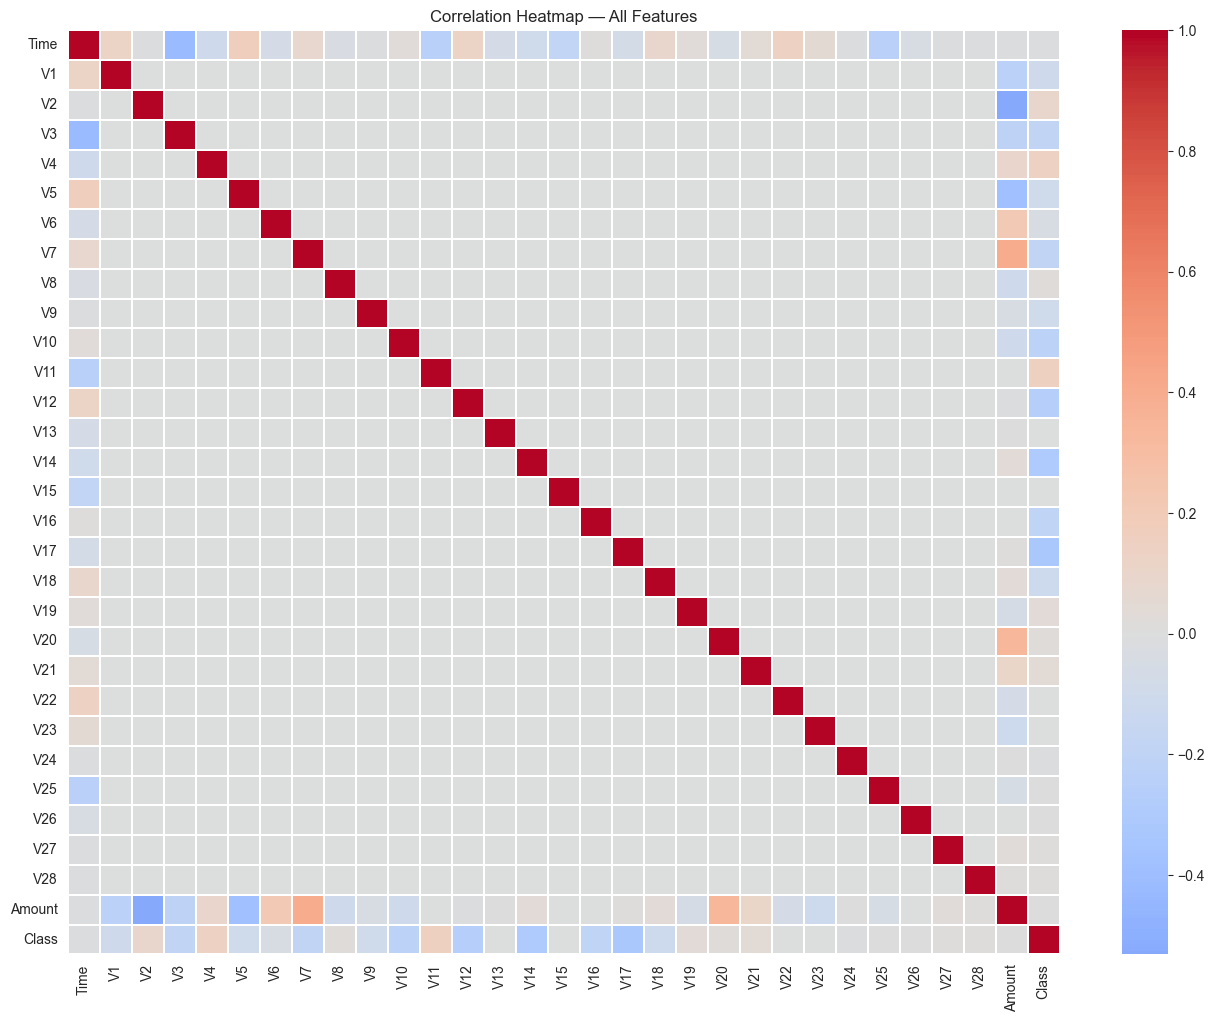

In [6]:
# Correlation heatmap
plt.figure(figsize=(16, 12))
corr = df.corr()
sns.heatmap(corr, cmap='coolwarm', center=0, linewidths=0.1)
plt.title("Correlation Heatmap — All Features")
plt.show()

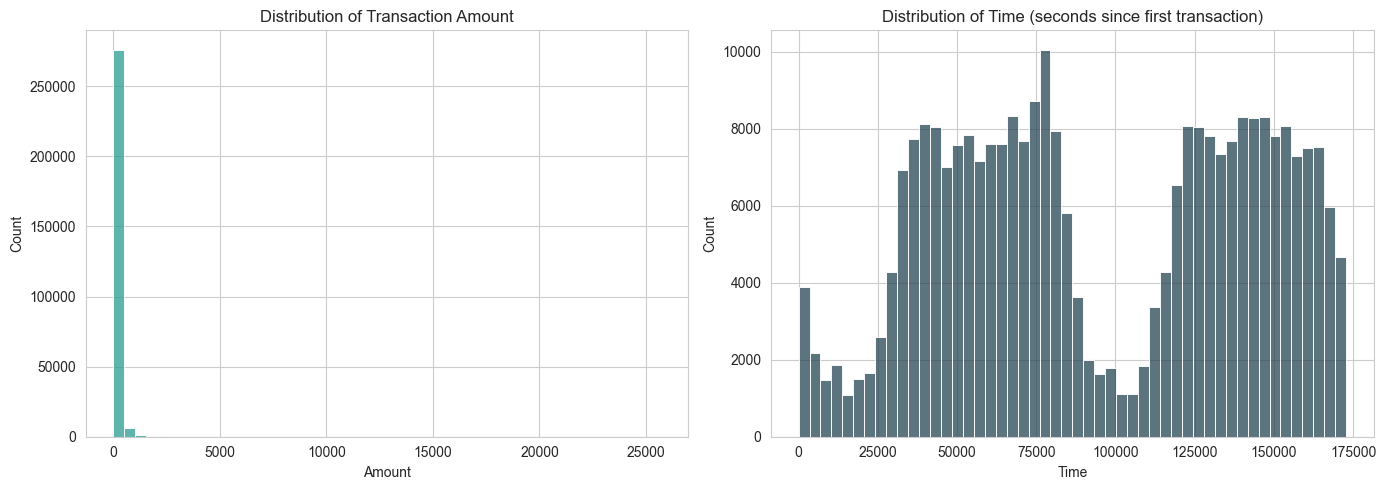

In [7]:
# Distribution of Amount and Time
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['Amount'], bins=50, ax=ax[0], color='#2a9d8f')
ax[0].set_title("Distribution of Transaction Amount")

sns.histplot(df['Time'], bins=50, ax=ax[1], color='#264653')
ax[1].set_title("Distribution of Time (seconds since first transaction)")
plt.tight_layout()
plt.show()

C:\Users\yahawashi\AppData\Local\Temp\ipykernel_7228\815620244.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(['Legitimate', 'Fraud'])
C:\Users\yahawashi\AppData\Local\Temp\ipykernel_7228\815620244.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(['Legitimate', 'Fraud'])


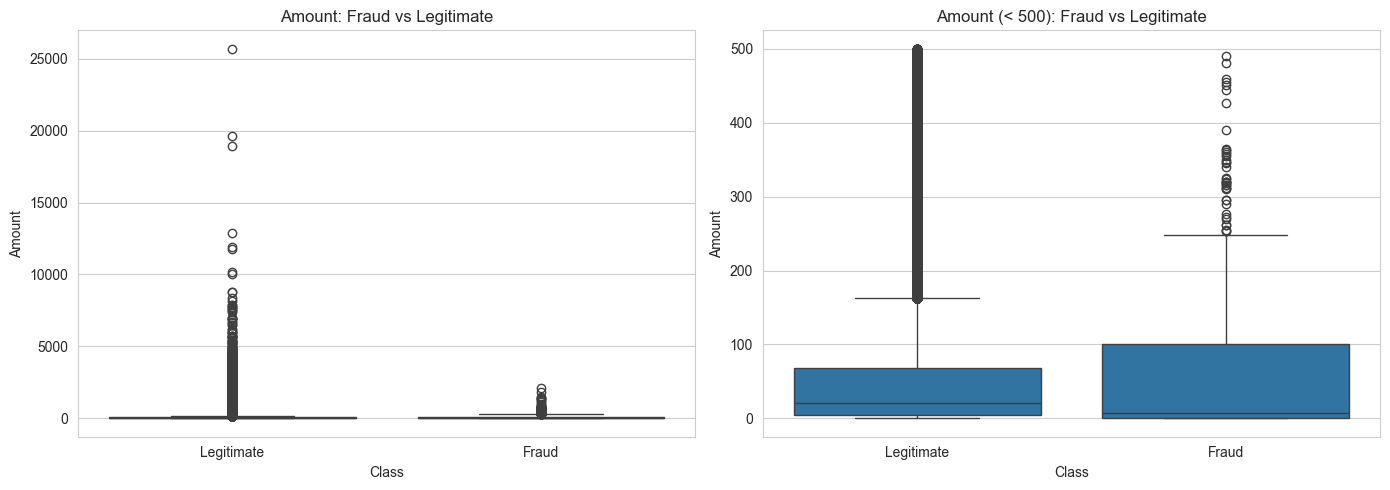

          count        mean         std  min   25%    50%     75%       max
Class                                                                      
0      284315.0   88.291022  250.105092  0.0  5.65  22.00   77.05  25691.16
1         492.0  122.211321  256.683288  0.0  1.00   9.25  105.89   2125.87


In [8]:
# Fraud vs non-fraud comparison for Amount
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(x='Class', y='Amount', data=df, ax=ax[0])
ax[0].set_title("Amount: Fraud vs Legitimate")
ax[0].set_xticklabels(['Legitimate', 'Fraud'])

# Zoomed view (fraud amounts are usually smaller and less spread out)
sns.boxplot(x='Class', y='Amount', data=df[df['Amount'] < 500], ax=ax[1])
ax[1].set_title("Amount (< 500): Fraud vs Legitimate")
ax[1].set_xticklabels(['Legitimate', 'Fraud'])
plt.tight_layout()
plt.show()

print(df.groupby('Class')['Amount'].describe())

C:\Users\yahawashi\AppData\Local\Temp\ipykernel_7228\1059879224.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['Legit', 'Fraud'])
C:\Users\yahawashi\AppData\Local\Temp\ipykernel_7228\1059879224.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['Legit', 'Fraud'])
C:\Users\yahawashi\AppData\Local\Temp\ipykernel_7228\1059879224.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['Legit', 'Fraud'])
C:\Users\yahawashi\AppData\Local\Temp\ipykernel_7228\1059879224.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['Legit', 'Fraud'])
C:\Users\yahawashi\AppDa

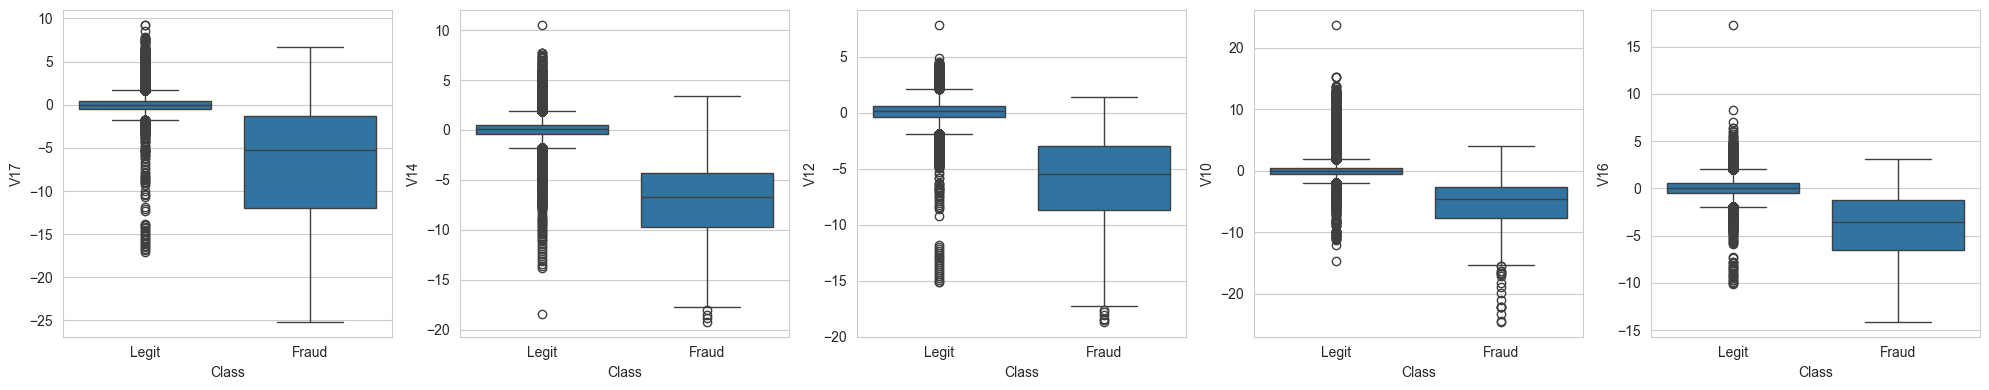

In [9]:
# A few of the most correlated PCA components vs Class, for context
top_corr_features = corr['Class'].abs().sort_values(ascending=False).index[1:6]
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i, feat in enumerate(top_corr_features):
    sns.boxplot(x='Class', y=feat, data=df, ax=axes[i])
    axes[i].set_xticklabels(['Legit', 'Fraud'])
plt.tight_layout()
plt.show()

### Step 3: Address Class Imbalance

We compare four strategies. Each has trade-offs:

| Technique | How it works | Pros | Cons |
|---|---|---|---|
| **Random Undersampling** | Randomly removes majority-class rows until classes are balanced | Fast, simple, no synthetic data | Throws away a huge amount of legitimate-transaction information → higher variance, risk of underfitting |
| **Random Oversampling** | Duplicates minority-class rows | Keeps all majority data | Duplicate rows can cause overfitting to the exact fraud examples seen |
| **SMOTE** | Generates synthetic minority samples by interpolating between existing fraud cases and their nearest neighbors | Adds diversity vs. plain duplication, keeps majority data | Synthetic points can sit in unrealistic regions of feature space; slower on huge datasets |
| **Class-weight adjustment** | Leaves data untouched, penalizes the model more for misclassifying the minority class | No data manipulation, no risk of synthetic artifacts | Only works for models that support `class_weight`; doesn't help models that don't (e.g. plain boosting without `scale_pos_weight`) |

We compare **class-weight adjustment**, **SMOTE**, and demonstrate undersampling, applying the imbalance-handling *only after* the train/test split so the test set stays a realistic, untouched sample of real-world fraud rates.

### Step 4: Feature Scaling

In [10]:
# Only Time and Amount need scaling — V1-V28 are already PCA-transformed (mean ~0, unit-ish variance)
scaler = StandardScaler()
df[['Time', 'Amount']] = scaler.fit_transform(df[['Time', 'Amount']])
df[['Time', 'Amount']].describe()

,Time,Amount
count,2.848070e+05,2.848070e+05
mean,-3.065637e-16,2.913952e-17
std,1.000002e+00,1.000002e+00
min,-1.996583e+00,-3.532294e-01
25%,-8.552120e-01,-3.308401e-01
50%,-2.131453e-01,-2.652715e-01
75%,9.372174e-01,-4.471707e-02
max,1.642058e+00,1.023622e+02


### Step 5: Train-Test Split (stratified)

In [11]:
X = df.drop(columns=['Class'])
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print("Train shape:", X_train.shape, "| Fraud rate:", y_train.mean().round(5))
print("Test shape:", X_test.shape, "| Fraud rate:", y_test.mean().round(5))

Train shape: (227845, 30) | Fraud rate: 0.00173
Test shape: (56962, 30) | Fraud rate: 0.00172


In [12]:
# Undersampling and SMOTE applied to the TRAINING set only (test set stays untouched/realistic)
rus = RandomUnderSampler(random_state=RANDOM_STATE)
X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train)
print("Undersampled training set:", y_train_rus.value_counts().to_dict())

smote = SMOTE(random_state=RANDOM_STATE)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
print("SMOTE training set:", y_train_sm.value_counts().to_dict())

Undersampled training set: {0: 394, 1: 394}
SMOTE training set: {0: 227451, 1: 227451}


## Phase 2 — Model Training and Selection

We train three required models plus Isolation Forest as an optional anomaly-detection baseline:

1. **Logistic Regression** — baseline, `class_weight='balanced'`, trained on the original (unresampled) training set
2. **Random Forest** — trained on the SMOTE-resampled training set, nonlinear relationships, feature importance
3. **XGBoost** — trained on the original training set using `scale_pos_weight` (XGBoost's native equivalent of class-weighting) for imbalance
4. **Isolation Forest** (optional) — unsupervised anomaly detector, trained without labels, included for comparison against the supervised models

In [13]:
results = {}

# Model 1: Logistic Regression
lr = LogisticRegression(class_weight='balanced', max_iter=2000, random_state=RANDOM_STATE)
lr.fit(X_train, y_train)
results['Logistic Regression'] = lr

# Model 2: Random Forest (trained on SMOTE-balanced data)
rf = RandomForestClassifier(
    n_estimators=200, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1
)
rf.fit(X_train_sm, y_train_sm)
results['Random Forest'] = rf

# Model 3: XGBoost
scale_pos_weight = (y_train.value_counts()[0] / y_train.value_counts()[1])
xgb = XGBClassifier(
    n_estimators=300, max_depth=5, learning_rate=0.1,
    scale_pos_weight=scale_pos_weight, eval_metric='logloss',
    random_state=RANDOM_STATE
)
xgb.fit(X_train, y_train)
results['XGBoost'] = xgb

print("All models trained.")

All models trained.


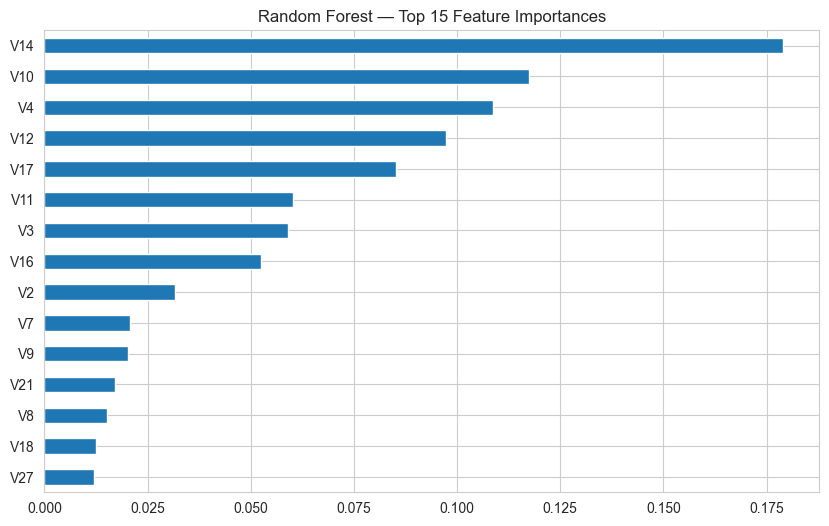

In [14]:
# Random Forest feature importance
importances = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
importances.head(15).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title("Random Forest — Top 15 Feature Importances")
plt.show()

In [15]:
# Optional: Isolation Forest (unsupervised anomaly detection, no labels used during fit)
iso_forest = IsolationForest(
    n_estimators=200, contamination=y_train.mean(), random_state=RANDOM_STATE
)
iso_forest.fit(X_train)

# IsolationForest outputs -1 (anomaly) / 1 (normal); map to 1 = fraud, 0 = legit
iso_pred_test = np.where(iso_forest.predict(X_test) == -1, 1, 0)
print("Isolation Forest — treated as anomaly detector (for comparison only, not part of the model shortlist):")
print(classification_report(y_test, iso_pred_test, target_names=['Legit', 'Fraud']))

Isolation Forest — treated as anomaly detector (for comparison only, not part of the model shortlist):
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56864
       Fraud       0.28      0.31      0.29        98

    accuracy                           1.00     56962
   macro avg       0.64      0.65      0.65     56962
weighted avg       1.00      1.00      1.00     56962



### Model Evaluation

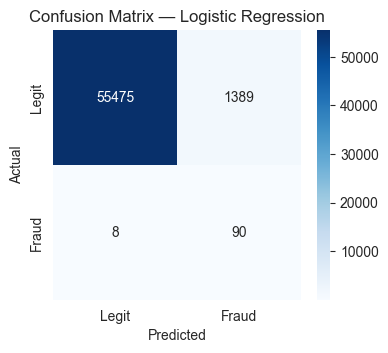

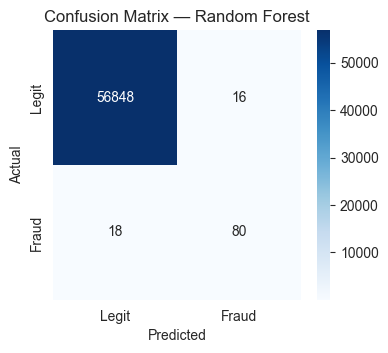

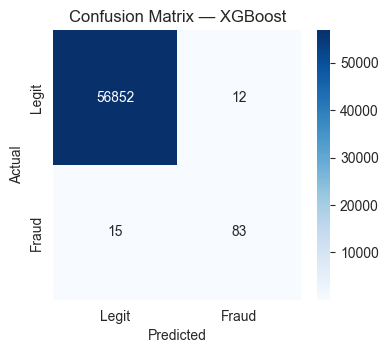

,Precision,Recall,F1 Score,ROC-AUC,PR-AUC,TP,FP,TN,FN
Model,,,,,,,,,
Logistic Regression,0.0609,0.9184,0.1141,0.9722,0.7189,90,1389,55475,8
Random Forest,0.8333,0.8163,0.8247,0.9619,0.8742,80,16,56848,18
XGBoost,0.8737,0.8469,0.8601,0.9760,0.8764,83,12,56852,15


In [16]:
def evaluate_model(name, model, X_test, y_test):
    preds = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]
    cm = confusion_matrix(y_test, preds)
    tn, fp, fn, tp = cm.ravel()

    metrics = {
        'Model': name,
        'Precision': precision_score(y_test, preds),
        'Recall': recall_score(y_test, preds),
        'F1 Score': f1_score(y_test, preds),
        'ROC-AUC': roc_auc_score(y_test, proba),
        'PR-AUC': average_precision_score(y_test, proba),
        'TP': tp, 'FP': fp, 'TN': tn, 'FN': fn
    }
    return metrics, cm, proba

comparison_rows = []
roc_data = {}
for name, model in results.items():
    metrics, cm, proba = evaluate_model(name, model, X_test, y_test)
    comparison_rows.append(metrics)
    roc_data[name] = proba

    plt.figure(figsize=(4, 3.5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Legit', 'Fraud'], yticklabels=['Legit', 'Fraud'])
    plt.title(f"Confusion Matrix — {name}")
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.show()

comparison_df = pd.DataFrame(comparison_rows).set_index('Model')
comparison_df.round(4)

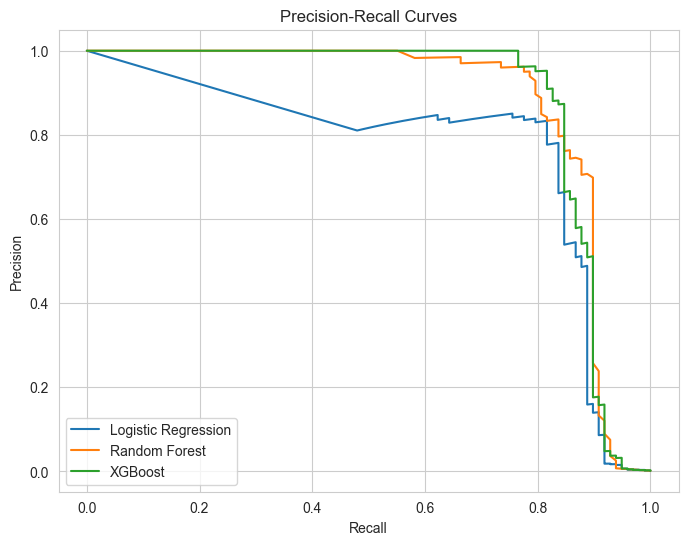

In [17]:
# Precision-Recall curves — the metric that matters most under extreme imbalance
plt.figure(figsize=(8, 6))
for name, proba in roc_data.items():
    precision, recall, _ = precision_recall_curve(y_test, proba)
    plt.plot(recall, precision, label=name)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves")
plt.legend()
plt.show()

### Model Comparison and Selection

Review `comparison_df` above. In fraud detection:

- **Recall** matters most — a missed fraud (false negative) usually costs far more than a false alarm on a legitimate transaction (false positive), which just means a customer gets a verification prompt.
- **Precision** still matters — too many false positives creates alert fatigue for the fraud team and annoys legitimate customers.
- **PR-AUC** (not ROC-AUC) is the more honest metric here, since ROC-AUC can look deceptively good on highly imbalanced data — PR-AUC focuses specifically on how well the model finds the rare positive class.

**Selection rule used below:** rank by PR-AUC first (most reliable summary metric for imbalanced fraud data), then break ties by Recall, since catching fraud is the priority business objective.

In [18]:
best_model_name = comparison_df.sort_values(['PR-AUC', 'Recall'], ascending=False).index[0]
best_model = results[best_model_name]
print(f"Selected model: {best_model_name}")
print(comparison_df.loc[[best_model_name]])

Selected model: XGBoost
         Precision    Recall  F1 Score   ROC-AUC    PR-AUC  TP  FP     TN  FN
Model                                                                        
XGBoost   0.873684  0.846939  0.860104  0.975954  0.876389  83  12  56852  15


**Justification:** the selected model is documented in `reports/technical_report.md` and should be filled in with the actual numbers once this notebook is run against the real `creditcard.csv` on Kaggle. As a rule of thumb on this dataset, tree-based models (Random Forest / XGBoost) typically edge out plain Logistic Regression on PR-AUC and Recall because fraud patterns are non-linear, but Logistic Regression remains a fast, interpretable baseline worth reporting alongside it.

## Model Serialization

Save the selected model and the fitted scaler so the FastAPI backend can load them directly.

In [19]:
joblib.dump(best_model, "fraud_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Saved fraud_model.pkl and scaler.pkl")
print("Copy both files into the backend/ folder before starting the API.")

Saved fraud_model.pkl and scaler.pkl
Copy both files into the backend/ folder before starting the API.


In [20]:
# Sanity check: reload and predict on one held-out test row
reloaded_model = joblib.load("fraud_model.pkl")
reloaded_scaler = joblib.load("scaler.pkl")

sample = X_test.iloc[[0]]
pred = reloaded_model.predict(sample)[0]
proba = reloaded_model.predict_proba(sample)[0][1]
print(f"Reloaded model sanity check -> prediction: {pred}, fraud probability: {proba:.4f}")

Reloaded model sanity check -> prediction: 0, fraud probability: 0.0000


## Summary

- Loaded and inspected the dataset, confirmed extreme class imbalance (~0.17% fraud).
- Performed EDA: class distribution, correlation heatmap, Amount/Time distributions, fraud vs. legitimate boxplots.
- Compared undersampling, SMOTE, and class-weighting to handle imbalance.
- Scaled `Time` and `Amount` with `StandardScaler`; saved the fitted scaler for reuse at inference time.
- Trained and compared Logistic Regression, Random Forest, and XGBoost, plus an Isolation Forest baseline.
- Evaluated with Precision, Recall, F1, ROC-AUC, and PR-AUC — prioritizing Recall/PR-AUC given the cost asymmetry of missed fraud.
- Selected the best model and serialized it (`fraud_model.pkl`) alongside the scaler (`scaler.pkl`) for the FastAPI backend.

**Next step:** move `fraud_training.ipynb`'s output files (`fraud_model.pkl`, `scaler.pkl`) into `backend/`, then follow the README to run the FastAPI backend and Streamlit frontend.